# Analyse des doublons 
Bronze => trop laborieux 
Silver ?

In [1]:
import sys
print(sys.executable)

/opt/homebrew/Cellar/jupyterlab/4.4.10/libexec/bin/python


In [2]:
!{sys.executable} -m pip install scikit-learn

In [3]:
import matplotlib.pyplot as plt
import re
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Accessing Storage Files: Bronze → Silver
Explore how to access and manipulate job files stored in the bronze and silver layers using `get_storage_from_env()` and the project environment configuration.

In [3]:
# Map du python path dans le docker
#import sys, os
#sys.path.insert(0, os.path.abspath('../..'))  # remonte à la racine du projet
#from src.config.env import load_project_env

## Load Project Environment
Import and load the project environment configuration to initialize environment variables.

In [4]:
#AS
import os
from pathlib import Path

print("Working dir:", os.getcwd())
print("Notebook file parent (approx):", Path().resolve())
print("Listing here:", sorted(p.name for p in Path().resolve().iterdir() if not p.name.startswith('.'))[:20])

Working dir: /Users/Agathe_1/Documents/Travail/DST/JobMarket/jan26_bde_jobmarket/notebooks/00_exploration/AS
Notebook file parent (approx): /Users/Agathe_1/Documents/Travail/DST/JobMarket/jan26_bde_jobmarket/notebooks/00_exploration/AS
Listing here: ['analyze_doublons.ipynb']


In [5]:
#AS
import sys
sys.path.insert(0, "../../..")  # <-- mets ici le dossier qui contient `src`

In [6]:
# Deactivate warning
import warnings
warnings.filterwarnings('ignore')

# Load project environment
from src.config.env import load_project_env
load_project_env()  # Safe to call multiple times (idempotent)
print("✅ Project environment loaded successfully")

✅ Project environment loaded successfully


## Create storage connections for silver layers using `get_storage_from_env()` for the 'welcometothejungle' source.

In [7]:
from src.storage.storage import get_storage_from_env
import src.utils.merge_dataset_utils as merge_utils
#import logging
#logger = logging.getLogger(__name__)

storage_wttj = get_storage_from_env("silver", "merged")

## Load wttj parquet file with helper

In [8]:
df = merge_utils.read_wttj_parquet_file_to_df(storage_wttj,"")

In [13]:
df.head(5)

,id,source,url,title,description,published_at,updated_at,unpublished_at,status,rome_code,...,company_name,company_city,company_postal_code,company_url,salary_min,salary_max,profile,location_department,skills,salary_periodicity
0,204NBKZ,FT,https://candidat.francetravail.fr/offres/reche...,Assistant.e d'élevage équin (H/F),Pour un élevage de 40 poulinières avec foals e...,2026-02-24 15:31:40.476,2026-02-24 15:31:40.476,None,published,A1309,...,,14335,14430,,0.0,0.0,,14,[],
1,9335081,FT,https://candidat.francetravail.fr/offres/reche...,agent technique hippodrome (H/F),Vos Missions : - Entretien des Pistes : Condui...,2026-02-20 05:13:55.000,2026-02-25 05:55:34.000,None,published,A1309,...,,,,,0.0,0.0,,,[],
2,203SBCC,FT,https://candidat.francetravail.fr/offres/reche...,Jardinier H/F,Description du poste : Vous aurez la responsab...,2026-02-06 10:42:37.623,2026-02-22 21:46:00.739,None,published,A1208,...,SCI DE QUINCAMPOIX,91411,91470,,0.0,0.0,,91,[],Mensuel de 2100.00 Euros à 2300.00 Euros sur 1...
3,203RYYK,FT,https://candidat.francetravail.fr/offres/reche...,Ouvrier / Ouvrière paysagiste (H/F),Nous sommes une société d'Aide à la personne s...,2026-02-06 10:16:53.979,2026-02-06 10:16:53.979,None,published,A1208,...,JARDI'N'AIDE,14001,14600,,0.0,0.0,,14,[],Horaire de 12.02 Euros à 12.33 Euros sur 12 mois
4,203RXQL,FT,https://candidat.francetravail.fr/offres/reche...,Jardinier / Jardinière paysagiste (H/F),*** Candidature à envoyer avant le 20/02/2026 ...,2026-02-06 09:51:57.665,2026-02-25 21:46:48.704,None,published,A1208,...,Parc de Wesserling,68151,68470,,0.0,0.0,,68,[],Horaire de 12.02 Euros


## Stats 

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 638047 entries, 0 to 638046
Data columns (total 29 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   id                      638047 non-null  str           
 1   source                  638047 non-null  str           
 2   url                     638047 non-null  str           
 3   title                   638047 non-null  str           
 4   description             638047 non-null  str           
 5   published_at            638047 non-null  datetime64[us]
 6   updated_at              638017 non-null  datetime64[us]
 7   unpublished_at          0 non-null       object        
 8   status                  638047 non-null  str           
 9   rome_code               638047 non-null  str           
 10  rome_label              638047 non-null  str           
 11  title_description       638047 non-null  str           
 12  contract_type           638047 non-null  

In [14]:
df['source'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%'

source
FT      92.0%
WTTJ     8.0%
Name: proportion, dtype: str

In [18]:
# 1. Nb offres par source
print("\n1. Nb offres par source\n", df.groupby('source')['id'].count())

# 2. Nb entreprises uniques par source
print("\n2. Nb entreprises uniques par source\n", df.groupby('source')['company_name'].nunique())

# 3. Entreprises présentes sur les deux plateformes
print("\n3. Entreprises présentes sur les deux plateformes\n")
ent_ft   = set(df[df['source']=='FT']['company_name'].str.lower().str.strip())
ent_wttj = set(df[df['source']=='WTTJ']['company_name'].str.lower().str.strip())
print(f"Entreprises sur FT seulement     : {len(ent_ft - ent_wttj)}")
print(f"Entreprises sur WTTJ seulement   : {len(ent_wttj - ent_ft)}")
print(f"Entreprises sur les deux         : {len(ent_ft & ent_wttj)}")

# 4. Distribution temporelle
print("\n4. Distribution temporelle\n", df.groupby('source')['published_at'].agg(['min', 'max']))


1. Nb offres par source
 source
FT      586768
WTTJ     51279
Name: id, dtype: int64

2. Nb entreprises uniques par source
 source
FT      66595
WTTJ        1
Name: company_name, dtype: int64

3. Entreprises présentes sur les deux plateformes

Entreprises sur FT seulement     : 65216
Entreprises sur WTTJ seulement   : 0
Entreprises sur les deux         : 1

4. Distribution temporelle
                        min                     max
source                                            
FT     2021-05-27 16:46:10 2026-03-03 14:19:42.685
WTTJ   2025-06-24 07:47:08 2026-02-28 04:00:40.000


In [20]:

# Regarder ce qu'il y a dans company_name pour WTTJ
print(df[df['source']=='WTTJ']['company_name'].value_counts().head(10))

company_name
    51279
Name: count, dtype: int64


In [21]:
print(df[df['source']=='WTTJ'][['title', 'description', 'company_url', 'profile']].head(3).to_string())


                                                                     title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [22]:
# company_url donne peut-être le slug de l'entreprise
print(df[df['source']=='WTTJ']['company_url'].value_counts().head(10))


company_url
    51279
Name: count, dtype: int64


## Doublons ?
- il faut 'source' de valeurs différentes
- après normalisation de qqch ? 
- sur quels critères on teste

In [13]:
# Nb et % par source
source_counts = df['source'].value_counts()
source_pct = (df['source'].value_counts(normalize=True) * 100).round(1)

pd.DataFrame({
    'nb_offres': source_counts,
    'pct': source_pct.astype(str) + '%'
})

,nb_offres,pct
source,,
FT,586768,92.0%
WTTJ,51279,8.0%


In [14]:
cols = ['title', 'company_name', 'job_city', 'published_at']

print("=== France Travail ===")
df[df['source'] == 'FT'][cols].sort_values('title').head(10)

=== France Travail ===


,title,company_name,job_city,published_at
10584,"""Adjoint au chef de culture en pépinière"" (H/F)",,59 - Gruson,2026-01-07 03:00:40
10591,"""Adjoint au chef de culture en pépinière"" (H/F)",,49 - Ménitré,2026-01-07 03:00:37
230980,"""Agent Paysage Jardins & Espaces Verts Saisonn...",,80 - Rosières-en-Santerre,2026-01-07 03:00:40
230981,"""Agent Paysage Jardins & Espaces Verts Saisonn...",,69 - Sathonay-Camp,2026-01-07 03:00:39
230982,"""Agent Paysage Jardins & Espaces Verts Saisonn...",,64 - Denguin,2026-01-07 03:00:36
9463,"""Agent Vigne & Vin Saisonnier F-H"" (H/F)",,26 - Tain-l'Hermitage,2026-01-07 03:00:35
9518,"""Agent Vigne & Vin Saisonnier F-H"" (H/F)",,49 - Cléré-sur-Layon,2026-03-03 03:00:34
9549,"""Agent Vigne & Vin Saisonnier F-H"" (H/F)",,49 - Lys-Haut-Layon,2026-02-28 03:00:37
9550,"""Agent Vigne & Vin Saisonnier F-H"" (H/F)",,24 - Pomport,2026-02-28 03:00:37
9551,"""Agent Vigne & Vin Saisonnier F-H"" (H/F)",,49 - Lys-Haut-Layon,2026-02-28 03:00:37


In [15]:
print("=== WTTJ ===")
df[df['source'] == 'WTTJ'][cols].sort_values('title').head(10)

=== WTTJ ===


,title,company_name,job_city,published_at
614909,# - Ingénieur / technicien travaux junior - (F...,,,2026-02-23 15:05:53
631119,# Ingénieur travaux à Cherbourg (50) - (F/H) -...,,,2026-02-23 15:01:33
618118,(CDI) Consultant senior en stratégie digitale ...,,,2026-02-25 12:39:14
621567,(EN/FR) Stage IA manipulation robotique (Imita...,,,2026-02-05 08:31:56
631994,(H/F) AI & Controls Engineer – Manipulation,,,2026-02-23 14:08:00
617150,(H/F) Développeur C++ Robotique Linux Senior,,,2026-02-24 08:43:30
604985,(H/F) IT Manager,,,2026-01-30 15:23:04
633211,"(H/F) R&D - Perception, Mapping and Navigation...",,,2026-02-13 08:46:19
633622,(Janvier 2026) - Stage / Alternance - Développ...,,,2026-02-20 10:00:39
636573,(M/W) Customer Solutions Engineer – Robotics,,,2026-02-17 09:42:36


In [16]:
#est ce que je peux trouver un même titre approx
mask = df['title'].str.contains('adjoint au chef', case=False, na=False)
df[mask][['title', 'source']].sort_values('title')

,title,source
10584,"""Adjoint au chef de culture en pépinière"" (H/F)",FT
10591,"""Adjoint au chef de culture en pépinière"" (H/F)",FT
603831,ADJOINT AU CHEF CELLULE D'AIDE A LA DECISION /...,WTTJ
487027,ADJOINT AU CHEF CELLULE D'AIDE A LA DECISION /...,FT
618121,ADJOINT AU CHEF DE BUREAU COHERENCE D ENSEMBLE,WTTJ
...,...,...
518691,PREF92 ADJOINT AU CHEF DU BUREAU DE L'ASILE (H/F),FT
501596,SDLP - ADJOINT AU CHEF DU BUREAU DES FINANCES ...,FT
606160,SDLP - Adjoint au chef du bureau des finances ...,WTTJ
445690,SPP-2026-007 UN ADJOINT AU CHEF DE CENTRE - CI...,FT


In [17]:
df[mask].groupby('source').size()

source
FT      64
WTTJ    50
dtype: int64

### Titres en commun

In [18]:
titres_ft = set(df[df['source'] == 'FT']['title'].str.lower().str.strip())
titres_wttj = set(df[df['source'] == 'WTTJ']['title'].str.lower().str.strip())

titres_communs = titres_ft & titres_wttj
print(f"{len(titres_communs)} titres en commun\n")

4506 titres en commun



In [43]:
#display(titres_communs)

In [19]:
df[df['title'].str.lower().str.strip().isin(titres_communs)][['title', 'source']].sort_values('title')


,title,source
34333,- BOUCHER (H/F),FT
34702,- BOUCHER (H/F),FT
35661,- BOUCHER (H/F),FT
36673,- BOUCHER (H/F),FT
36674,- BOUCHER (H/F),FT
...,...,...
468413,Équipier polyvalent de nuit - H/F,FT
468872,Équipier polyvalent de nuit - H/F,FT
468875,Équipier polyvalent de nuit - H/F,FT
601724,Équipier polyvalent de nuit - H/F,WTTJ


### Tentative matching flou sur le titre

In [38]:
titles_ft   = df[df['source'] == 'FT'][['title', 'title_norm']].drop_duplicates()
titles_wttj = df[df['source'] == 'WTTJ'][['title', 'title_norm']].drop_duplicates()

In [42]:
print(titles_ft.shape[0], "titres FT")
print(titles_wttj.shape[0], "titres WTTJ")

238919 titres FT
33090 titres WTTJ


In [65]:

list_ft   = titles_ft['title_norm'].tolist()
list_wttj = titles_wttj['title_norm'].tolist()

# Vectorisation
vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,4))
all_titles = list_ft + list_wttj
tfidf_matrix = vectorizer.fit_transform(all_titles)

matrix_ft   = tfidf_matrix[:len(list_ft)]
matrix_wttj = tfidf_matrix[len(list_ft):]

# Matching par batch pour éviter les OOM
batch_size = 1000
results = []

for i in range(0, len(list_ft), batch_size):
    batch = matrix_ft[i:i+batch_size]
    scores = cosine_similarity(batch, matrix_wttj)
    best_idx = np.argmax(scores, axis=1)
    best_score = scores[np.arange(len(best_idx)), best_idx]
    
    for j, (idx, score) in enumerate(zip(best_idx, best_score)):
        if score >= 0.8:
            results.append({
                'title_ft': list_ft[i+j],
                'title_wttj': list_wttj[idx],
                'score': score
            })

df_matches = pd.DataFrame(results)
print(f"{len(df_matches)} paires trouvées")


62925 paires trouvées


In [63]:
df_matches.sort_values('score', ascending=False).head(10)


,title_ft,title_wttj,score
97545,ingnieure dveloppement logiciel embarqu exprim...,ingnieure dveloppement logiciel embarqu exprim...,1.0
63363,technicien vitrage automobile mecanicien,technicien vitrage automobile mecanicien,1.0
72538,ehpad las arribasehpadpsychologuetemps partiel,ehpad las arribasehpadpsychologuetemps partiel,1.0
85237,charg de clientle corporate cdd 6 mois,charg de clientle corporate cdd 6 mois,1.0
32900,manager restauration rapide auch rond point de...,manager restauration rapide auch rond point de...,1.0
89212,directeur directrice des ressources humaines,directeur directrice des ressources humaines,1.0
14315,responsable adjoint,responsable adjoint,1.0
15902,assistant achats,assistant achats,1.0
8976,responsable datelier,responsable datelier,1.0
94061,dveloppeur javaangular,dveloppeur javaangular,1.0


In [76]:
#nb de match par tranche de score
pd.cut(df_matches['score'], bins=[0.75, 0.8,
                                  0.85, 0.9,
                                  0.95, 1.0, 1.001]).value_counts().sort_index(ascending=False)

score
(1.0, 1.001]    10393
(0.95, 1.0]     15258
(0.9, 0.95]      7860
(0.85, 0.9]     12364
(0.8, 0.85]     17050
(0.75, 0.8]         0
Name: count, dtype: int64

### Tentative matching flou sur le titre/entreprise name/job_city/description 
On va nettoyer un peu les champs titre, company_name, job_city, description : lower case, supprimer les ponctuations, ...

In [20]:
def clean_text(text):
    if pd.isna(text):
        return ''
    text = text.lower().strip()
    text = re.sub(r'[^\w\s]', ' ', text)
    return text

df['title_clean'] = df['title'].apply(clean_text)
df['company_name_clean'] = df['company_name'].apply(clean_text)
df['job_city_clean'] = df['job_city'].apply(clean_text)
df['description_clean'] = df['description'].apply(clean_text)


In [21]:
df['text_combined'] = (
    df['title_clean'] + ' ' +
    df['company_name_clean'] + ' ' +
    df['job_city_clean'] + ' ' +
    df['description_clean']
)

In [ ]:
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(df['text_combined'])

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Récupérer les paires avec score > seuil
threshold = 0.8
matches = []

for i in range(len(cosine_sim)):
    for j in range(i+1, len(cosine_sim)):
        if cosine_sim[i][j] >= threshold:
            matches.append({
                'idx1': i,
                'idx2': j,
                'score': cosine_sim[i][j]
            })

matches_df = pd.DataFrame(matches)
print(f"Doublons détectés : {len(matches_df)}")


## Contracts

In [19]:
# contract_counts = df['contract_type'].value_counts()
contract_counts_by_source = df.groupby('source')['contract_type'].value_counts()

In [18]:
display(df.loc[(df['source']=='WTTJ') & df['title'].notna()].sort_values('title')[['title','source']].head(150))

,title,source
614909,# - Ingénieur / technicien travaux junior - (F...,WTTJ
631119,# Ingénieur travaux à Cherbourg (50) - (F/H) -...,WTTJ
618118,(CDI) Consultant senior en stratégie digitale ...,WTTJ
621567,(EN/FR) Stage IA manipulation robotique (Imita...,WTTJ
631994,(H/F) AI & Controls Engineer – Manipulation,WTTJ
...,...,...
606642,ACHETEUR,WTTJ
630077,ACHETEUR,WTTJ
615245,ACHETEUR MARCHES COMPLEXES,WTTJ
587358,ACHETEUR NEGOCIATEUR,WTTJ


### Avant normalisation

In [31]:
display(df_normalize_contract_counts_by_source.head(30))
#print(f" Libellé unique = {len(contract_counts_by_source)}")


source  contract_normalized                         
FT      CDI                                             311669
        Intérim                                         157945
        CDD                                              85304
        Profession libérale                              14239
        Saisonnier                                        9849
        Profession commerciale                            4704
        Franchise                                         3034
        Reprise d'entreprise                                21
        Contrat durée déterminée insertion - 12 Mois         1
        Reprise d'entreprise - 12 Mois                       1
        Contrat durée déterminée insertion - 24 Mois         1
WTTJ    full_time                                        31945
        temporary                                        11150
        internship                                        4152
        apprenticeship                                    2234
  

 Libellé unique = 513


### Après normalisation 

In [24]:
def normalize_contracts(df, patterns):
    """
    Normalise les types de contrat :
    - Extrait le type principal (CDI, CDD, Intérim, etc.)
    - Extrait le détail (durée, précision)
    - Stocke dans contract_normalized et contract_detail
    """
    def extract_type(value):
        if pd.isna(value):
            return 'Inconnu'
        for pattern, label in patterns:
            if re.search(pattern, str(value)):
                return label
        return str(value)  # garder la valeur originale si pas de match

    def extract_detail(value):
        if pd.isna(value):
            return None
        # Supprimer le pattern trouvé et retourner le reste
        remaining = str(value)
        for pattern, label in patterns:
            remaining = re.sub(pattern, '', remaining).strip()
        # Nettoyer les séparateurs résiduels (-, :, espaces)
        remaining = re.sub(r'^[\s\-:]+|[\s\-:]+$', '', remaining)
        return remaining if remaining else None
    
    df = df.copy()
    df['contract_normalized'] = df['contract_type'].apply(extract_type)
    df['contract_detail']     = df['contract_type'].apply(extract_detail)
    
    return df


In [25]:
def plot_contract_by_source(df, source, contract_column):
    # Filtrer par source
    df_source = df[df['source'] == source]
    
    # Calcul en pourcentage
    contract_pct = df_source[contract_column].value_counts(normalize=True).mul(100).round(1)
    
    # Graphique
    fig, ax = plt.subplots(figsize=(10, 5))
    contract_pct.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    
    # Afficher les % sur les barres
    for i, v in enumerate(contract_pct):
        ax.text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')
    
    ax.set_title(f"Répartition des types de contrat — {source}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Type de contrat")
    ax.set_ylabel("Pourcentage (%)")
    ax.set_ylim(0, contract_pct.max() + 10)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


Modalités de contrats FT = 11
Modalités de contrats WTTJ = 10


source  contract_normalized                         
FT      CDI                                             311669
        Intérim                                         157945
        CDD                                              85304
        Profession libérale                              14239
        Saisonnier                                        9849
        Profession commerciale                            4704
        Franchise                                         3034
        Reprise d'entreprise                                21
        Contrat durée déterminée insertion - 12 Mois         1
        Reprise d'entreprise - 12 Mois                       1
        Contrat durée déterminée insertion - 24 Mois         1
WTTJ    full_time                                        31945
        temporary                                        11150
        internship                                        4152
        apprenticeship                                    2234
  

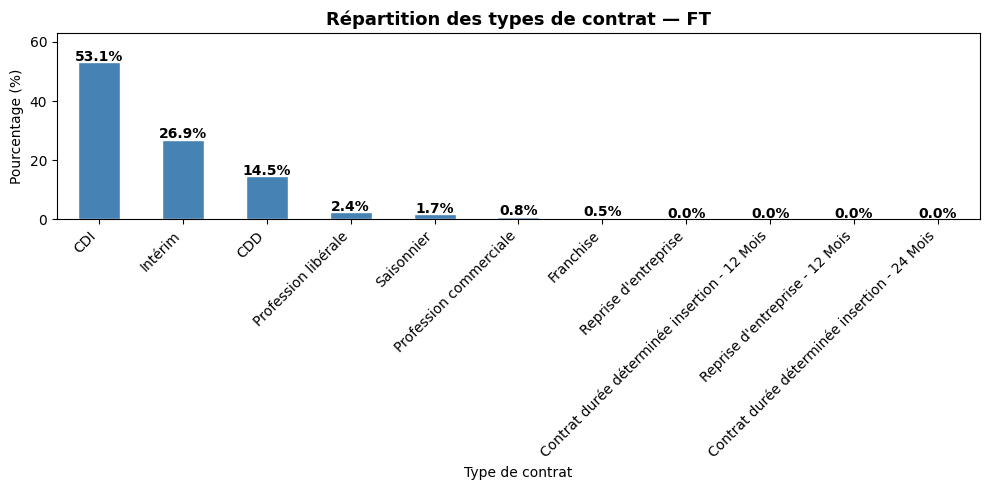

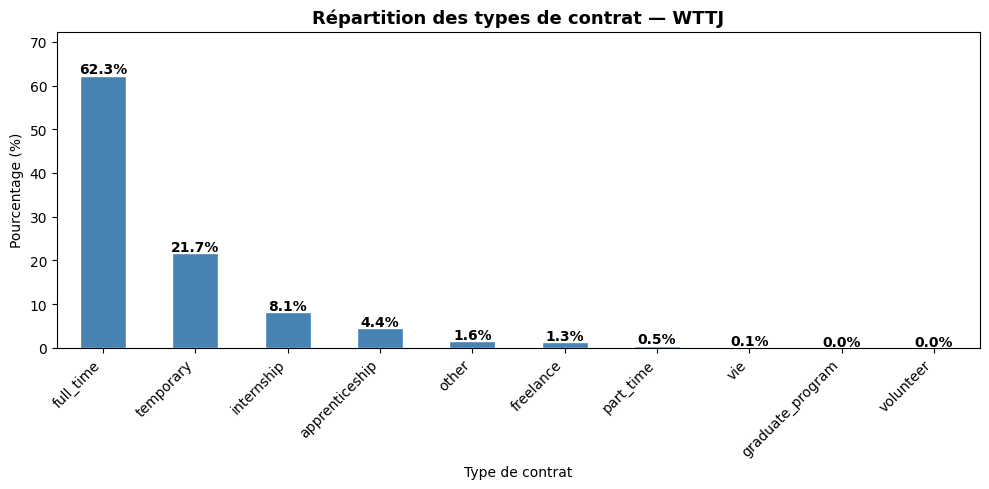

In [26]:
# Mapping des patterns => type normalisé
patterns = [
    (r'(?i)cdi',                'CDI'),
    (r'(?i)contrat à durée indéterminée',                'CDD'),
    (r'(?i)cdd',                'CDD'),
    (r'(?i)contrat à durée déterminée',                'CDD'),
    (r'(?i)profession\s+lib',   'Profession libérale'),
    (r'(?i)intér?im',           'Intérim'),
    (r'(?i)saisonnier',           'Saisonnier'),
    (r'(?i)profession commerciale',     'Profession commerciale'),
    (r'(?i)franchise',     'Franchise')    
]

# Apply
df_normalize = normalize_contracts(df, patterns)

df_normalize_contract_counts_by_source = df_normalize.groupby('source')['contract_normalized'].value_counts()
print(f"Modalités de contrats FT = {len(df_normalize_contract_counts_by_source.loc['FT'])}")
print(f"Modalités de contrats WTTJ = {len(df_normalize_contract_counts_by_source.loc['WTTJ'])}")

display(df_normalize_contract_counts_by_source.head(30))

plot_contract_by_source(df_normalize, 'FT', 'contract_normalized')
plot_contract_by_source(df_normalize, 'WTTJ', 'contract_normalized')


### Expérience

In [32]:
experience_level_counts_by_source = df.groupby('source')['experience_level'].value_counts()
experience_description_counts_by_source = df.groupby('source')['experience_description'].value_counts()

### Avant normalisation

**FT**
- experienceExige => D : débutant accepté, E : l’expérience est exigée, S : l’expérience est souhaitée
- experienceLibelle => Libellé de l’expérience ex : Débutant accepté / 1 ans ... 
- experienceCommentaire => Commentaire sur l’expérience. Ex: Expérience dans la vente souhaitée

On a pas la bonne correspondance de colonne.
Il faut prendre `experience_level` pour `wttj` et `experience_description` pour FT


In [33]:
display(experience_level_counts_by_source.head(30))


source  experience_level  
FT      E                     307688
        D                     279066
        S                         14
WTTJ    LESS_THAN_6_MONTHS     16688
        5_TO_7_YEARS            3132
        4_TO_5_YEARS            2890
        2_TO_3_YEARS            2480
        1_TO_2_YEARS            2095
        3_TO_4_YEARS            1830
        6_MONTHS_TO_1_YEAR      1136
        7_TO_10_YEARS            483
        10_TO_15_YEARS           461
        MORE_THAN_15_YEARS        31
Name: count, dtype: int64

In [34]:
display(experience_description_counts_by_source.head(30))

source  experience_description          
FT      Débutant accepté                    276159
        1 An(s)                              91518
        2 An(s)                              67695
        3 An(s)                              42951
        Expérience exigée                    35264
        5 An(s)                              19507
        6 Mois                                9175
        0 An(s)                               4707
        12 Mois                               3976
        6 An(s)                               3660
        4 An(s)                               2605
        24 Mois                               1867
        3 Mois                                1555
        10 An(s)                              1335
        7 An(s)                               1233
        1 Mois                                 859
        36 Mois                                553
        2 Mois                                 523
        8 An(s)                          

In [35]:
# Définition des tranches d'expérience avec leurs indices
EXPERIENCE_LEVELS = [
    (0, 'Débutant',    [r'(?i)débutant', r'(?i)0 an', r'(?i)sans expérience']),
    (1, '0-1 an',      [r'(?i)^1 an', r'(?i)^6 mois', r'(?i)^1 mois', r'(?i)^3 mois', r'(?i)less_than_6_months', r'(?i)6_months_to_1_year']),
    (2, '1-2 ans',     [r'(?i)^2 an', r'(?i)1_to_2_years']),
    (3, '2-3 ans',     [r'(?i)^3 an', r'(?i)^24 mois', r'(?i)2_to_3_years' ]),
    (4, '3-5 ans',     [r'(?i)^4 an', r'(?i)^5 an', r'(?i)4_to_5_years', r'(?i)3_to_4_years']),
    (5, '5-10 ans',    [r'(?i)^6 an', r'(?i)^7 an', r'(?i)^8 an', r'(?i)^9 an', r'(?i)^10 an', r'(?i)5_to_7_years', r'(?i)7_to_10_years']),
    (6, '10+ ans',     [r'(?i)^1[1-9] an', r'(?i)^[2-9][0-9] an', r'(?i)10_to_15_years', r'(?i)more_than_15_years']),
    (-1, 'Non précisé', [r'(?i)expérience exigée', r'(?i)expérience souhaitée']),
   
]

def normalize_experience(df, experience_col):
    """
    Normalise les niveaux d'expérience :
    - experience_normalized : label lisible (ex: '0-1 an')
    - experience_index      : indice numérique (ex: 1) pour trier/comparer
    - experience_detail     : valeur originale nettoyée
    """

    def extract_experience(value):
        if pd.isna(value):
            #To DEBUG
            return -1, 'NAN', None
            #return -1, 'Non précisé', None
        
        str_value = str(value).strip()
        
        for index, label, patterns in EXPERIENCE_LEVELS:
            for pattern in patterns:
                if re.search(pattern, str_value):
                    # Détail = valeur originale
                    return index, label, str_value
        
        #return -1, 'Non précisé', str_value
        # To debug
        return -1, value, str_value
    

    results = df[experience_col].apply(extract_experience)
    
    df = df.copy()
    df['experience_index']      = results.apply(lambda x: x[0])
    df['experience_normalized'] = results.apply(lambda x: x[1])
    df['experience_detail']     = results.apply(lambda x: x[2])
    
    return df


In [36]:
def get_experience_col(row):
    if row['source'] == 'FT':
        return row['experience_description']
    elif row['source'] == 'WTTJ':
        return row['experience_level']
    else:
        return None 

df_normalize['experience_source_composite'] = df.apply(get_experience_col, axis=1)

# Utilisation
df_normalize = normalize_experience(df_normalize,'experience_source_composite')

# Vérification
#df_normalize[['experience_source_composite', 'experience_index', 'experience_normalized', 'experience_detail']].head(20)

display(df_normalize.groupby('source')['experience_normalized'].value_counts())

source  experience_normalized
FT      Débutant                 285311
        0-1 an                   112006
        1-2 ans                   71678
        2-3 ans                   46660
        Non précisé               35282
                                  ...  
WTTJ    3-5 ans                    4720
        5-10 ans                   3615
        2-3 ans                    2480
        1-2 ans                    2095
        10+ ans                     492
Name: count, Length: 434, dtype: int64

## ROME

In [38]:
rome_count = df['rome_code'].value_counts()
print(rome_count)

rome_code
K1304    11963
J1501    10656
J1506    10652
C1504    10488
M1211     9968
         ...  
M1845        1
M1857        1
M1865        1
N4130        1
N4124        1
Name: count, Length: 1506, dtype: int64


## Statistics from helper

In [39]:
if df is not None and not df.empty:
    merge_utils.print_statistics(df)
else    :
    logger.warning("⚠️ Aucune donnée chargée pour les statistiques FT/WTTJ fusionnées")


📊 STATISTICS OF THE MERGED DATASET

📈 GLOBAL STATISTICS
   Total offers: 638,047

📦 DISTRIBUTION BY SOURCE
   FT: 586,768 offers (92.0%)
   WTTJ: 51,279 offers (8.0%)

📌 ROME COVERAGE BY SOURCE
   FT: 586,768/586,768 offers with ROME (100.0%)
   WTTJ: 51,279/51,279 offers with ROME (100.0%)

🎯 ROME CODES
   Offers with ROME: 638,047 (100.0%)
   Unique ROME codes: 1506

🏆 TOP 10 ROME CODES
   K1304: 11,963 (1.9%) - Employé familial / Employée familiale
   J1501: 10,656 (1.7%) - Aide-soignant / Aide-soignante
   J1506: 10,652 (1.7%) - Infirmier / Infirmière en soins généraux (IDE)
   C1504: 10,488 (1.6%) - Conseiller / Conseillère immobilier
   M1211: 9,968 (1.6%) - Expert-comptable / Experte-comptable
   M1203: 9,046 (1.4%) - Comptable
   I1304: 7,599 (1.2%) - Technicien / Technicienne de maintenance industrielle
   K1311: 7,492 (1.2%) - Assistant / Assistante de vie aux familles
   D1507: 7,287 (1.1%) - Employé / Employée de rayon libre-service
   H2903: 6,829 (1.1%) - Tourneur-fraise

KeyError: 'contract_normalized'